In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


In [2]:
df = pd.read_csv(r"/kaggle/input/datasets/organizations/uciml/iris/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df = df.drop("Id", axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
22,4.6,3.6,1.0,0.2,Iris-setosa
15,5.7,4.4,1.5,0.4,Iris-setosa
65,6.7,3.1,4.4,1.4,Iris-versicolor
11,4.8,3.4,1.6,0.2,Iris-setosa
42,4.4,3.2,1.3,0.2,Iris-setosa


In [5]:
test.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
73,6.1,2.8,4.7,1.2,Iris-versicolor
18,5.7,3.8,1.7,0.3,Iris-setosa
118,7.7,2.6,6.9,2.3,Iris-virginica
78,6.0,2.9,4.5,1.5,Iris-versicolor
76,6.8,2.8,4.8,1.4,Iris-versicolor


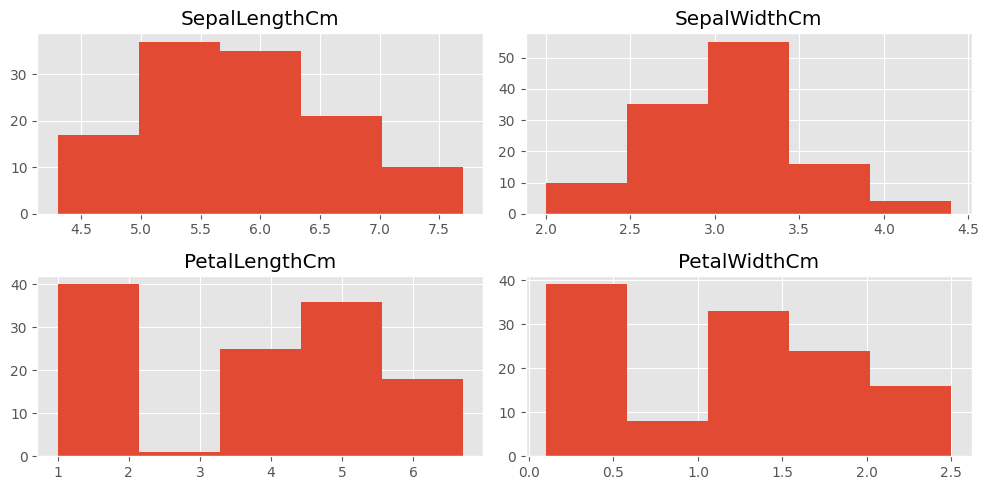

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

train.hist(figsize=(10,5), bins=5)
plt.tight_layout()
plt.show()

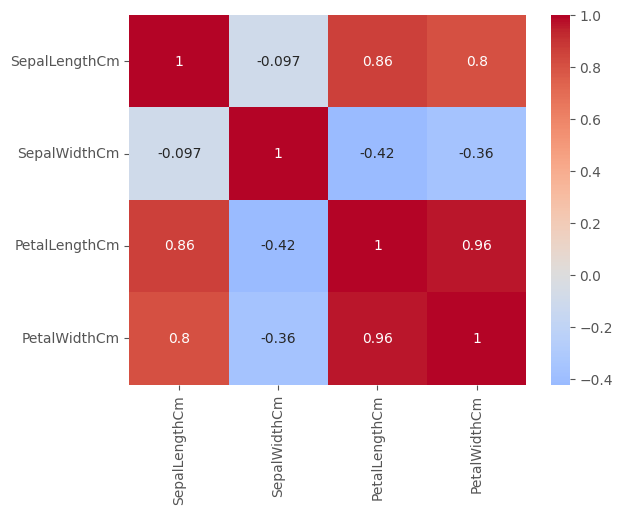

In [11]:
sns.heatmap(train.corr(numeric_only = True), annot=True, center=0, cmap="coolwarm")
plt.show()

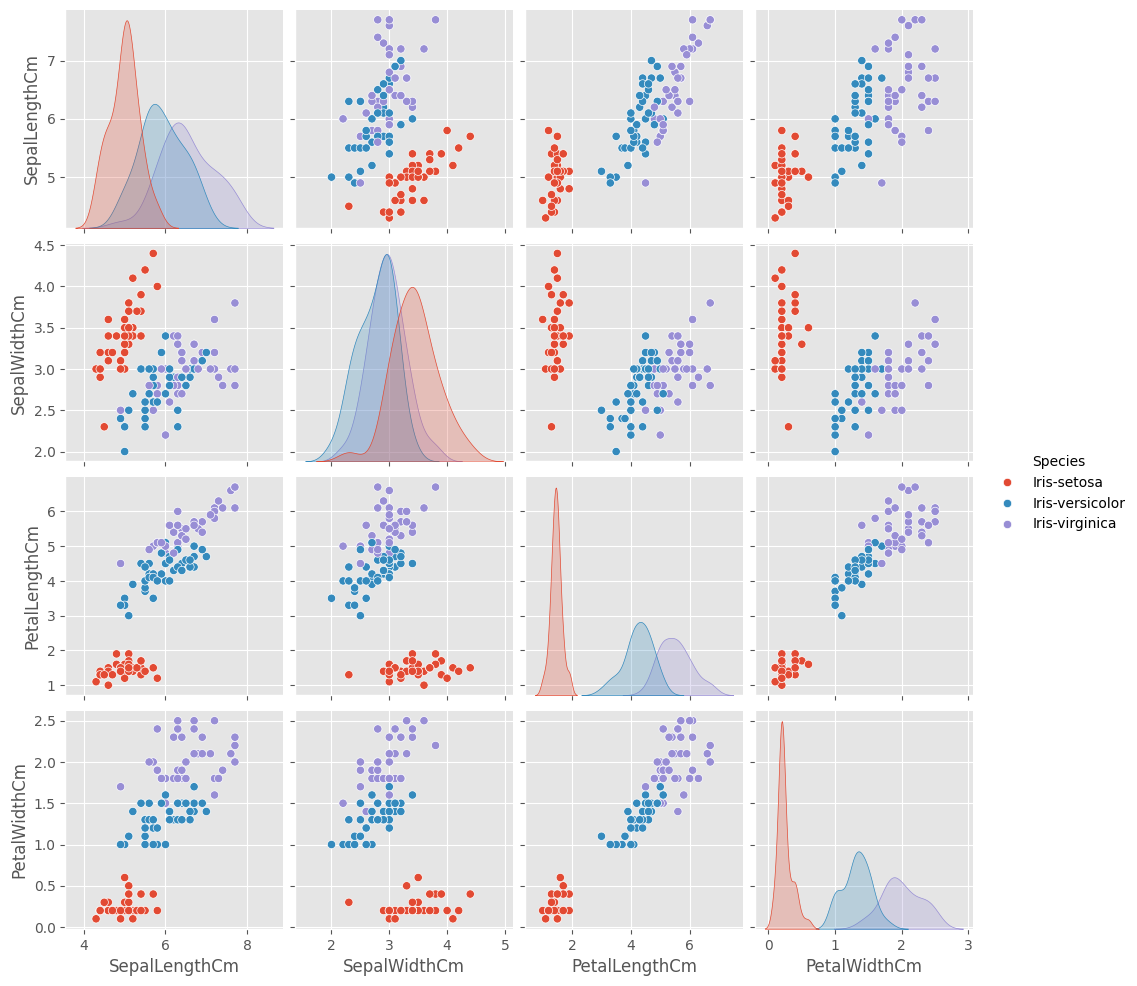

In [14]:
sns.pairplot(train, hue="Species")
plt.show()

- Iris Setosa

- 
![Iris Setosa](https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Irissetosa1.jpg/500px-Irissetosa1.jpg)

- Iris Versicolor
![Iris Versicolor](https://upload.wikimedia.org/wikipedia/commons/thumb/2/27/Blue_Flag%2C_Ottawa.jpg/960px-Blue_Flag%2C_Ottawa.jpg)

- Iris Virginica
![Iris Virginica](https://upload.wikimedia.org/wikipedia/commons/thumb/f/f8/Iris_virginica_2.jpg/960px-Iris_virginica_2.jpg)

- Iris Setosa is the most different as visible from the photos (source: wikipedia) from the other two varieties
- Virginica has more petal area than Versicolor, key differentiator for us

In [19]:
def make_features(df):
    df = df.copy()
    df["PetalAreaCm2"] = df["PetalLengthCm"] * df["PetalWidthCm"]
    df["TotalLengthCm"] = df["PetalLengthCm"] + df["SepalLengthCm"]
    df["WidthDiffCm"] = df["PetalWidthCm"] - df["SepalWidthCm"]
    FEATURES = ["PetalAreaCm2", "TotalLengthCm", "WidthDiffCm", "Species"]
    return df[FEATURES]

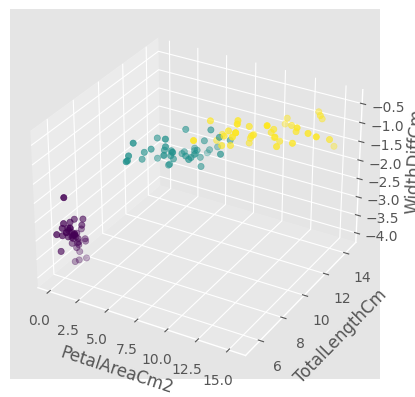

In [23]:
train_new = make_features(train)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    train_new["PetalAreaCm2"],
    train_new["TotalLengthCm"],
    train_new["WidthDiffCm"],
    c=train_new["Species"].astype("category").cat.codes 
)

ax.set_xlabel('PetalAreaCm2')
ax.set_ylabel('TotalLengthCm')
ax.set_zlabel('WidthDiffCm')

plt.show()

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = train_new.drop("Species", axis=1)
y_train = train_new["Species"]

X_train = scaler.fit_transform(X_train)

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

knn_cheb = KNeighborsClassifier(n_neighbors=5, metric='chebyshev')

knn_cheb.fit(X_train, y_train)

KNeighborsClassifier(metric='chebyshev')

In [34]:
X_test = scaler.transform(make_features(test).drop("Species", axis=1))
y_test = make_features(test)["Species"]

In [35]:
y_pred = knn_cheb.predict(X_test)

In [36]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score Obtained: {acc}")

Accuracy Score Obtained: 1.0


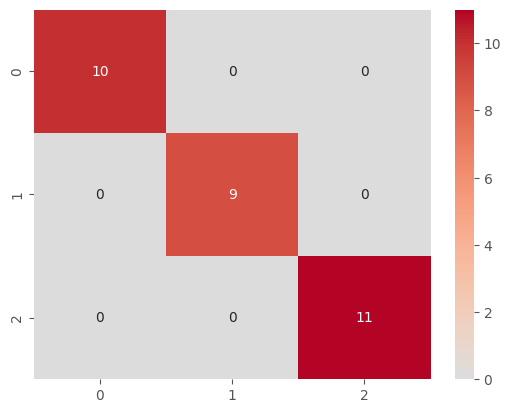

In [37]:
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, cmap="coolwarm", center=0)
plt.show()

## Test Set Accuracy Score: 100%

In [41]:
from sklearn.model_selection import cross_val_score

df_new = make_features(df)
X = df_new.drop("Species", axis=1)
y = df_new["Species"]

scores = cross_val_score(knn_cheb, scaler.fit_transform(X), y, cv=5)

print(f"Scores for each fold: {scores}")
print(f"Mean Accuracy: {scores.mean():.2f}")
print(f"Standard Deviation: {scores.std():.2f}")

Scores for each fold: [0.96666667 0.96666667 0.9        0.9        1.        ]
Mean Accuracy: 0.95
Standard Deviation: 0.04


## We get a Mean Accuracy of 95% over 5 Folds of Cross Validation